推定された臨界点 γ_c ≈ 0.87280
スケーリング係数 a ≈ -0.71139
臨界指数 ν ≈ 1.394


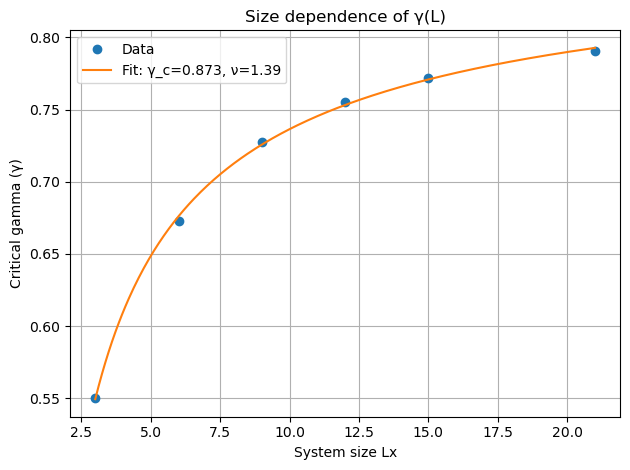

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ======= データ入力 ===========
# サイズ L と 対応するガンマ γ_p(L)
L = np.array([3, 6, 9, 12, 15, 21])  # 例
gamma_p = np.array([0.55, 0.6727, 0.7276, 0.7552, 0.7718, 0.7905])  # 仮の値

# ======= フィッティング関数の定義 ===========
def scaling_func(L, gamma_c, a, nu_inv):  # nu_inv = 1/ν
    return gamma_c + a * L ** (-nu_inv)

# ======= 非線形フィッティング ===========
popt, pcov = curve_fit(scaling_func, L, gamma_p)
gamma_c, a, nu_inv = popt
nu = 1 / nu_inv

# ======= 結果の表示 ===========
print(f"推定された臨界点 γ_c ≈ {gamma_c:.5f}")
print(f"スケーリング係数 a ≈ {a:.5f}")
print(f"臨界指数 ν ≈ {nu:.3f}")

# ======= フィッティング結果のプロット ===========
L_fit = np.linspace(min(L), max(L), 300)
gamma_fit = scaling_func(L_fit, *popt)

plt.plot(L, gamma_p, 'o', label='Data')
plt.plot(L_fit, gamma_fit, '-', label=f'Fit: γ_c={gamma_c:.3f}, ν={nu:.2f}')
plt.xlabel('System size Lx')
plt.ylabel('Critical gamma (γ)')
plt.title('Size dependence of γ(L)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


γ_c ≈ 0.87280
a ≈ -0.71139
ν ≈ 1.394


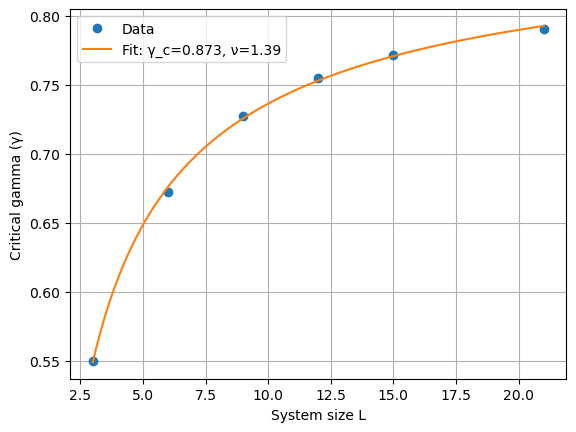

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

L = np.array([3, 6, 9, 12, 15, 21])  # 例
gamma_p = np.array([0.55, 0.6727, 0.7276, 0.7552, 0.7718, 0.7905])  # 仮の値

def scaling_func(L, gamma_c, a, nu_inv):
    return gamma_c + a * L ** (-nu_inv)

p0 = [0.8, -1.0, 1.0]  # 初期値
bounds = ([0, -np.inf, 0], [1, np.inf, 5])  # γ_c in [0,1], 1/ν positive and <=5

popt, pcov = curve_fit(scaling_func, L, gamma_p, p0=p0, bounds=bounds)
gamma_c, a, nu_inv = popt
nu = 1 / nu_inv

print(f"γ_c ≈ {gamma_c:.5f}")
print(f"a ≈ {a:.5f}")
print(f"ν ≈ {nu:.3f}")

L_fit = np.linspace(min(L), max(L), 300)
plt.plot(L, gamma_p, 'o', label='Data')
plt.plot(L_fit, scaling_func(L_fit, *popt), '-', label=f'Fit: γ_c={gamma_c:.3f}, ν={nu:.2f}')
plt.xlabel('System size L')
plt.ylabel('Critical gamma (γ)')
plt.legend()
plt.grid()
plt.show()


スケーリング係数 a ≈ -0.70372
臨界指数 ν ≈ 2.392


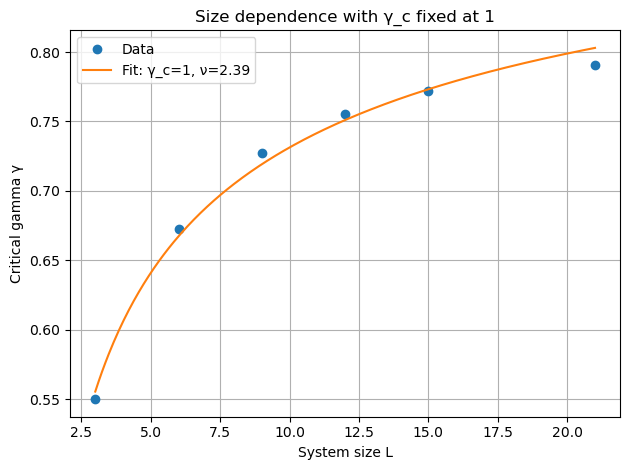

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データ
L = np.array([3, 6, 9, 12, 15, 21])  # 例
gamma_p = np.array([0.55, 0.6727, 0.7276, 0.7552, 0.7718, 0.7905])  # 仮の値

# γ_cを固定した関数
def scaling_fixed_gamma_c(L, a, nu_inv):
    gamma_c = 1.0
    return gamma_c + a * L ** (-nu_inv)

# 初期値
p0 = [-1.0, 1.0]

# フィット実行
popt, pcov = curve_fit(scaling_fixed_gamma_c, L, gamma_p, p0=p0)
a, nu_inv = popt
nu = 1 / nu_inv

print(f"スケーリング係数 a ≈ {a:.5f}")
print(f"臨界指数 ν ≈ {nu:.3f}")

# プロット
L_fit = np.linspace(min(L), max(L), 300)
gamma_fit = scaling_fixed_gamma_c(L_fit, *popt)

plt.plot(L, gamma_p, 'o', label='Data')
plt.plot(L_fit, gamma_fit, '-', label=f'Fit: γ_c=1, ν={nu:.2f}')
plt.xlabel('System size L')
plt.ylabel('Critical gamma γ')
plt.title('Size dependence with γ_c fixed at 1')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
